In [1]:
# These two lines allow for the notebook to automatically update to use the most
# up-to-date versions of the code being imported
%load_ext autoreload
%autoreload 2

import control as ct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyphotonicsims.control_systems.control_core import *
from pyphotonicsims.control_systems.calculate_laser_noise import *

# plt.style.available
%matplotlib inline
plt.style.use('science')
plt.rcParams['figure.figsize'] = [4,3]
import matplotlib
matplotlib.rcParams['text.usetex'] = False

c:\Users\lkk12\Documents\code\pyphotonicsims\.venv\Lib\site-packages\control\lti.py:646: FutureWarning: freqresp() is deprecated; use frequency_response()
  warn("freqresp() is deprecated; use frequency_response()", FutureWarning)


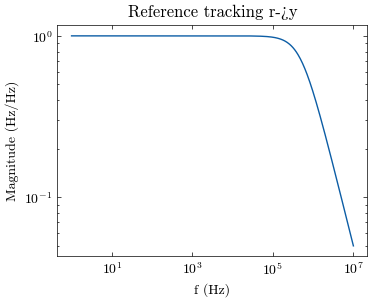

In [2]:
freq_points = 500
s = ct.tf('s')
sys = 10e6/(1 + s/(2*np.pi*1e5))
plant = ControlModule(freq_points = freq_points, sys_ref = sys, unit_in = 'V', unit_out = 'Hz')
plant.output_noise = np.ones(freq_points)*1e4

sys = 0.5e-6*(1 + 2*np.pi*1e5/s)
servo = ControlModule(freq_points = freq_points, sys_ref = sys, unit_in = 'Hz', unit_out = 'V')

C_list = [servo,plant]
laser = feedback_combine(C_list,1)
laser.input_noise = np.ones(freq_points)*1e2
laser.freqresp_module_update()

laser.plot_ref_tracking()

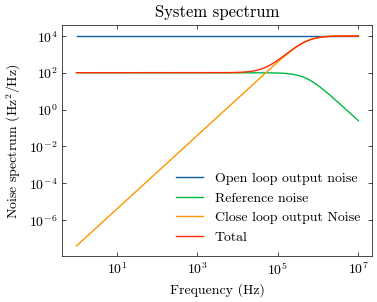

In [3]:
laser.plot_module_noise()

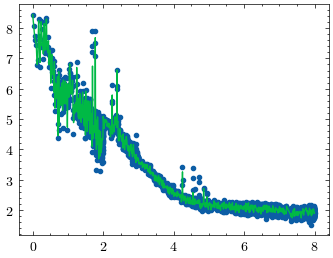

In [5]:
df = pd.read_csv('../data/ML_FN_data.csv')
FN = df.values
freqx = np.logspace(0,8,1000)
FNx = S_noise_interp(FN[:,0],FN[:,1],freqx, ifplot = 1)